# Model Evaluation Results


In [10]:
import os

import matplotlib.pyplot as plt

from evaluate_utils import (
    read_model_results,
    plot_model_loss,
    plot_model_loss_all,
    read_ground_truth_zip,
)
from plot_utils import set_plot_style

RESULTS_DIR = 'results/model'
RADIANCE_DIR = '../data/radiance'
EXTINCTIONS = 80, 200, 1000
CAMERAS = 'front', 'turntable'

set_plot_style()

In [11]:
results = {}
for subdir in os.listdir(RESULTS_DIR):
    subdir_path = os.path.join(RESULTS_DIR, subdir)
    if not os.path.isdir(subdir_path) or subdir not in CAMERAS:
        continue
    results[subdir] = read_model_results(subdir_path)

## Transfer Function 1


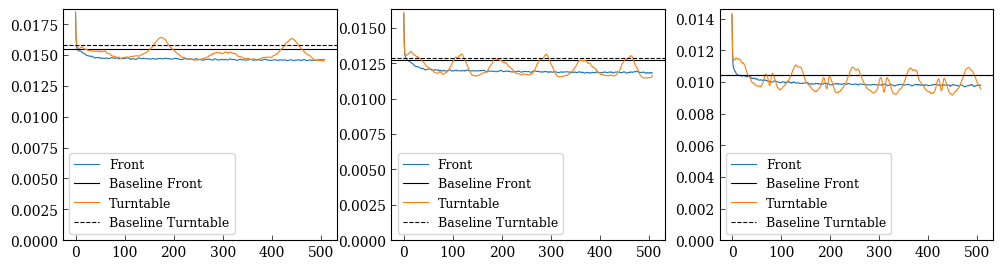

In [12]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        plot_model_loss(
            ax[i],
            results[camera],
            ('chameleon', extinction, 1),
            label=camera.capitalize(),
            styles={
                'baseline': dict(color='k', linestyle=('--', '-')[camera == 'front']),
            },
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## Transfer Function 2


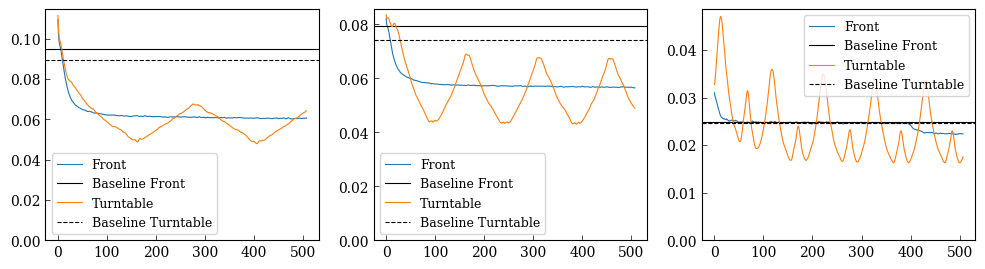

In [13]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        plot_model_loss(
            ax[i],
            results[camera],
            ('chameleon', extinction, 2),
            label=camera.capitalize(),
            styles={
                'baseline': dict(color='k', linestyle=('--', '-')[camera == 'front']),
            },
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## Transfer Function 3


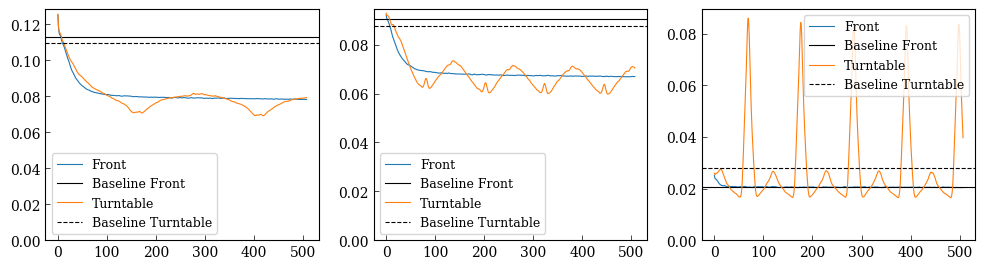

In [14]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        plot_model_loss(
            ax[i],
            results[camera],
            ('chameleon', extinction, 3),
            label=camera.capitalize(),
            styles={
                'baseline': dict(color='k', linestyle=('--', '-')[camera == 'front']),
            },
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## All Losses


### Chameleon


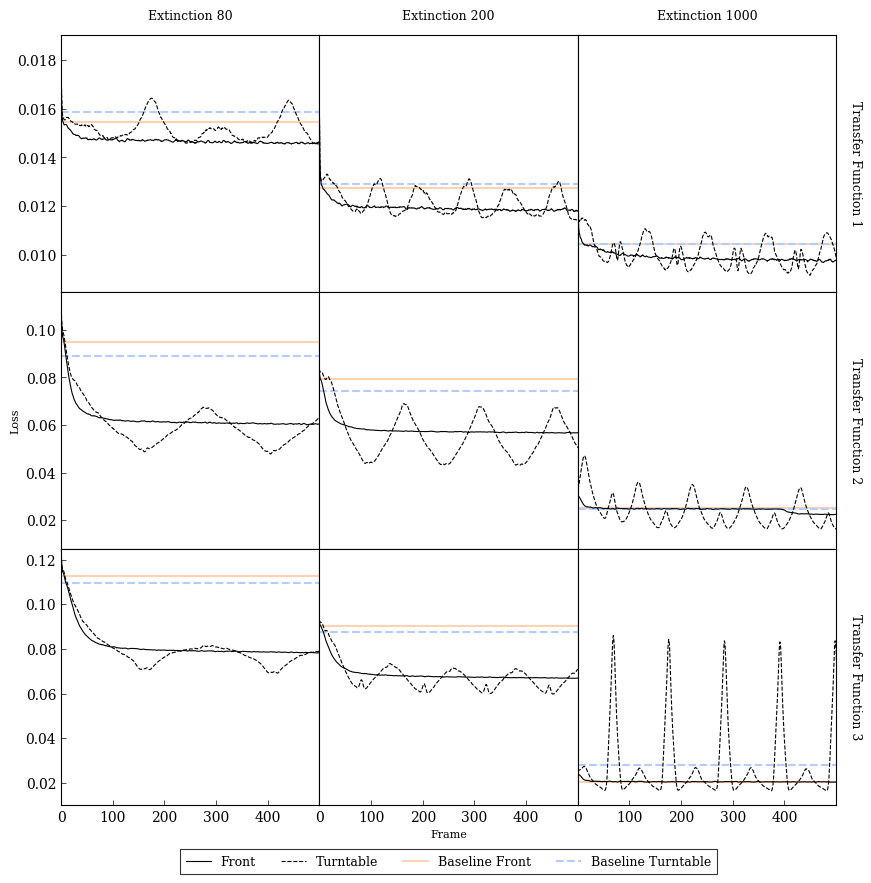

In [20]:
ylims = [(0.0085, 0.019), (0.008, 0.116), (0.01, 0.125)]
plot_model_loss_all(results, 'chameleon', ylims, layers=['front', 'turntable'])
plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'model_losses_chameleon.pdf'),
    bbox_inches='tight',
)
plt.show()

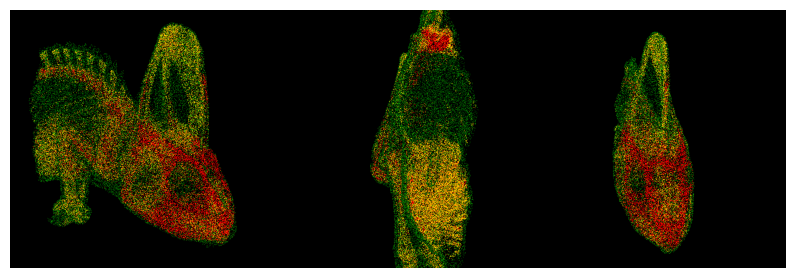

In [16]:
_, ax = plt.subplots(1, 3, figsize=(10, 10))

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_front_chameleon_200_3.zip'),
    'indirect_radiance_0000.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[0].imshow(radiance)
plt.imsave(
    os.path.join(RESULTS_DIR, 'images', 'radiance_chameleon_front.png'), radiance
)

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_turntable_chameleon_200_3.zip'),
    'indirect_radiance_0080.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[1].imshow(radiance)
plt.imsave(
    os.path.join(RESULTS_DIR, 'images', 'radiance_chameleon_insides.png'), radiance
)

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_turntable_chameleon_200_3.zip'),
    'indirect_radiance_0135.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[2].imshow(radiance)
plt.imsave(os.path.join(RESULTS_DIR, 'images', 'radiance_chameleon_head.png'), radiance)

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

### MRI Ventricles


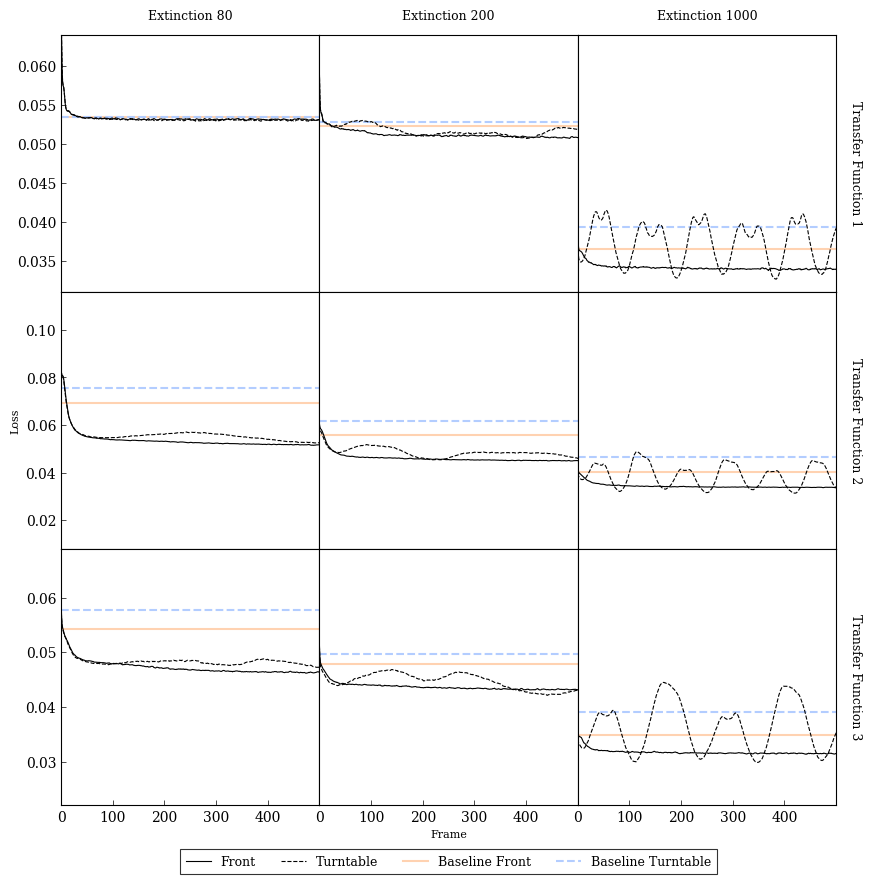

In [17]:
ylims = [(0.031, 0.064), (0.008, 0.116), (0.022, 0.069)]
plot_model_loss_all(results, 'mri_ventricles', ylims, layers=['front', 'turntable'])
plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'model_losses_mri_ventricles.pdf'),
    bbox_inches='tight',
)
plt.show()

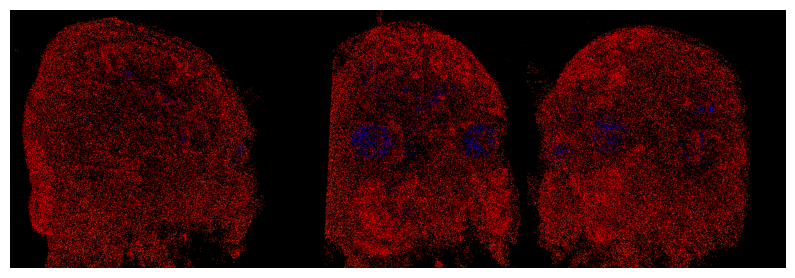

In [18]:
_, ax = plt.subplots(1, 3, figsize=(10, 10))

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_front_mri_ventricles_200_3.zip'),
    'indirect_radiance_0000.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[0].imshow(radiance)
plt.imsave(
    os.path.join(RESULTS_DIR, 'images', 'radiance_mri_ventricles_front.png'), radiance
)

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_turntable_mri_ventricles_200_3.zip'),
    'indirect_radiance_0170.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[1].imshow(radiance)
plt.imsave(
    os.path.join(RESULTS_DIR, 'images', 'radiance_mri_ventricles_eyes.png'), radiance
)

array, parameters = read_ground_truth_zip(
    os.path.join(RADIANCE_DIR, 'model_turntable_mri_ventricles_200_3.zip'),
    'indirect_radiance_0320.bin',
)
frame = array
height = parameters['resolution']
radiance = frame[:, 5:].reshape(height, height, 3)
ax[2].imshow(radiance)
plt.imsave(
    os.path.join(RESULTS_DIR, 'images', 'radiance_mri_ventricles_other.png'), radiance
)

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()